In [8]:
import numpy as np

In [9]:
import matplotlib.pyplot as plt

未安装相应包，安装后 报错解决

In [2]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [10]:
height, width = 256, 256   # 图像尺寸

每一次重新进入之后需要重新导入一遍库，不然会报错

In [11]:
# 每一列的灰度值从0到255线性变化
smooth_image = np.tile(np.arange(width, dtype=np.uint8), (height, 1))

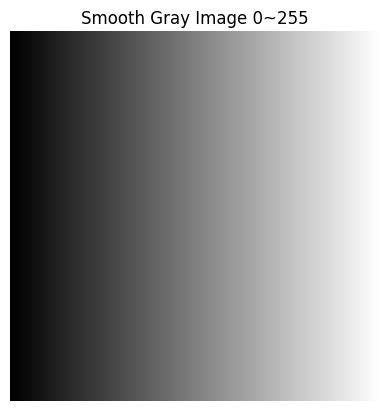

In [12]:
# 显示
plt.imshow(smooth_image, cmap='gray', vmin=0, vmax=255)
plt.title("Smooth Gray Image 0~255")
plt.axis('off')
plt.show()

In [13]:
# 每 16 像素灰度增加 16
band_width = 16
band_values = np.arange(0, 256, band_width, dtype=np.uint8)
mach_image = np.tile(band_values, (height, 1))

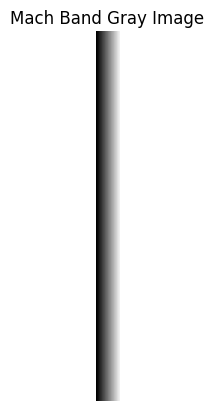

In [16]:
# 显示
plt.imshow(mach_image, cmap='gray', vmin=0, vmax=255)
plt.title("Mach Band Gray Image")
plt.axis('off')
plt.show()

In [15]:
# 每个 band 宽16像素，灰度值递增16
step_size = 16
bands = width // step_size
step_image = np.zeros((height, width), dtype=np.uint8)

for i in range(bands):
    step_image[:, i*step_size:(i+1)*step_size] = i * step_size

C:\Users\26971\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\26971\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\26971\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28784 (\N{CJK UNIFIED IDEOGRAPH-7070}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\26971\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\26971\AppData\Local\Programs\Python

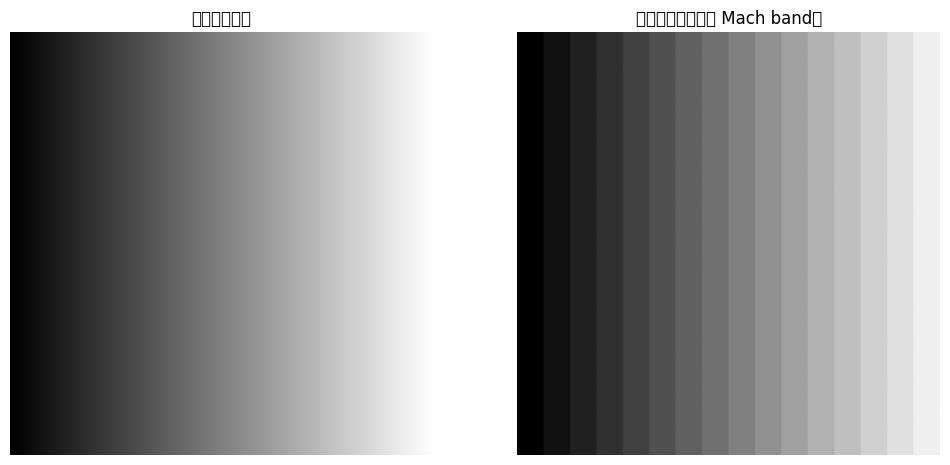

In [17]:
# 显示图像
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(smooth_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('平滑灰阶渐变')
axes[0].axis('off')

axes[1].imshow(step_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('阶梯灰阶图（观察 Mach band）')
axes[1].axis('off')

plt.show()

字体缺失导致的报错

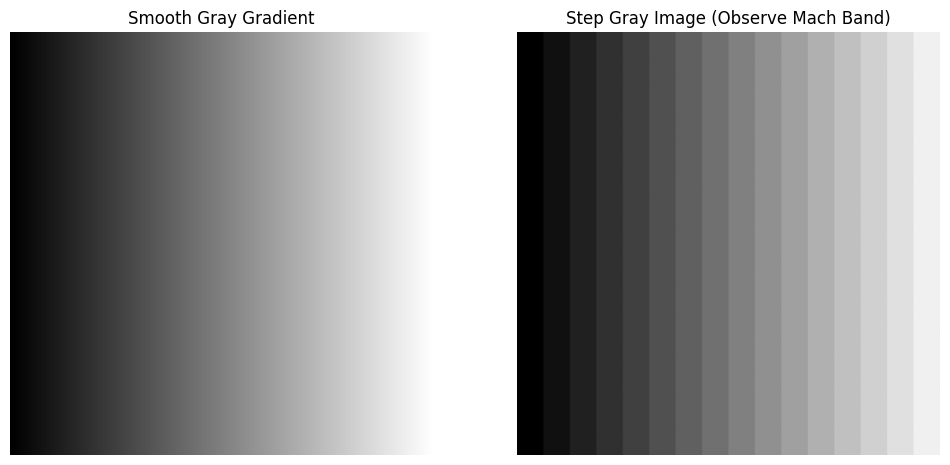

In [18]:
# 显示图像
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(smooth_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Smooth Gray Gradient')
axes[0].axis('off')

axes[1].imshow(step_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Step Gray Image (Observe Mach Band)')
axes[1].axis('off')

plt.show()

Smooth image shape: (256, 256)
Step image shape: (256, 256)
Step size per band: 16
Number of bands: 16


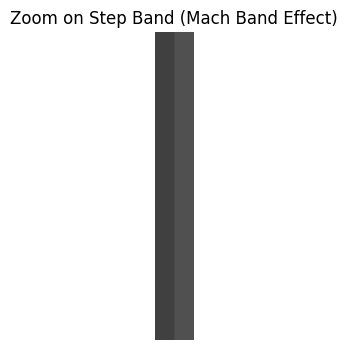

In [20]:
# 保存图像到文件
fig.savefig("gray_images.png", dpi=150)

# 打印一些信息
print("Smooth image shape:", smooth_image.shape)
print("Step image shape:", step_image.shape)
print("Step size per band:", step_size)
print("Number of bands:", bands)

# 突出 Mach band 效果，显示局部放大
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 4))
# 放大第5个band的边界
zoom_band = step_image[:, 64:96]
ax2.imshow(zoom_band, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Zoom on Step Band (Mach Band Effect)')
ax2.axis('off')
plt.show()

In [21]:
import scipy.io as sio

ModuleNotFoundError: No module named 'scipy'

In [22]:
import scipy.io as sio

In [27]:
# 读取 .mat 文件
mat_path = r"D:\课程\专业课\生物医学图像处理\lab1\lab1.mat"
mat_data = sio.loadmat(mat_path)

# 查看变量
print(mat_data.keys())  # dict_keys(['__header__', '__version__', '__globals__', 'data'])


dict_keys(['__header__', '__version__', '__globals__', 'data'])


Image shape: (361, 361)


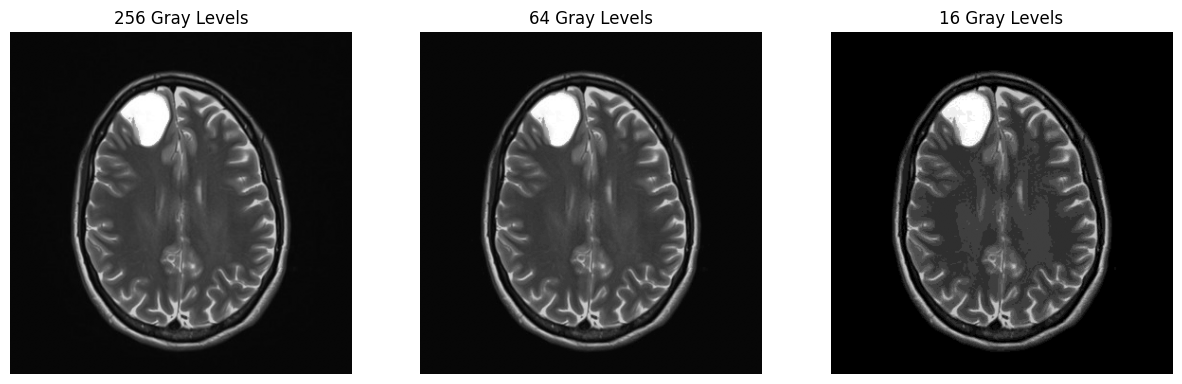

In [28]:
# 取出实际图像数组
image_struct = mat_data['data']

# 如果是嵌套数组（常见结构），取第一个元素
if isinstance(image_struct, np.ndarray) and image_struct.dtype == 'object':
    image = image_struct[0, 0]  # 提取真实图像
else:
    image = image_struct

print("Image shape:", image.shape)

# 定义灰度减少函数
def reduce_gray_levels(img, n):
    levels = 2 ** n
    img_normalized = img / 255.0                  # 归一化到0~1
    img_quantized = np.floor(img_normalized * levels) / levels  # 量化
    img_out = (img_quantized * 255).astype(np.uint8)           # 放大回0~255
    return img_out

# 生成不同灰度级图像
img_256 = reduce_gray_levels(image, 8)  # 256级灰度
img_64  = reduce_gray_levels(image, 6)  # 64级灰度
img_16  = reduce_gray_levels(image, 4)  # 16级灰度

# 显示图像
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_256, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('256 Gray Levels')
axes[0].axis('off')

axes[1].imshow(img_64, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('64 Gray Levels')
axes[1].axis('off')

axes[2].imshow(img_16, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('16 Gray Levels')
axes[2].axis('off')

plt.show()

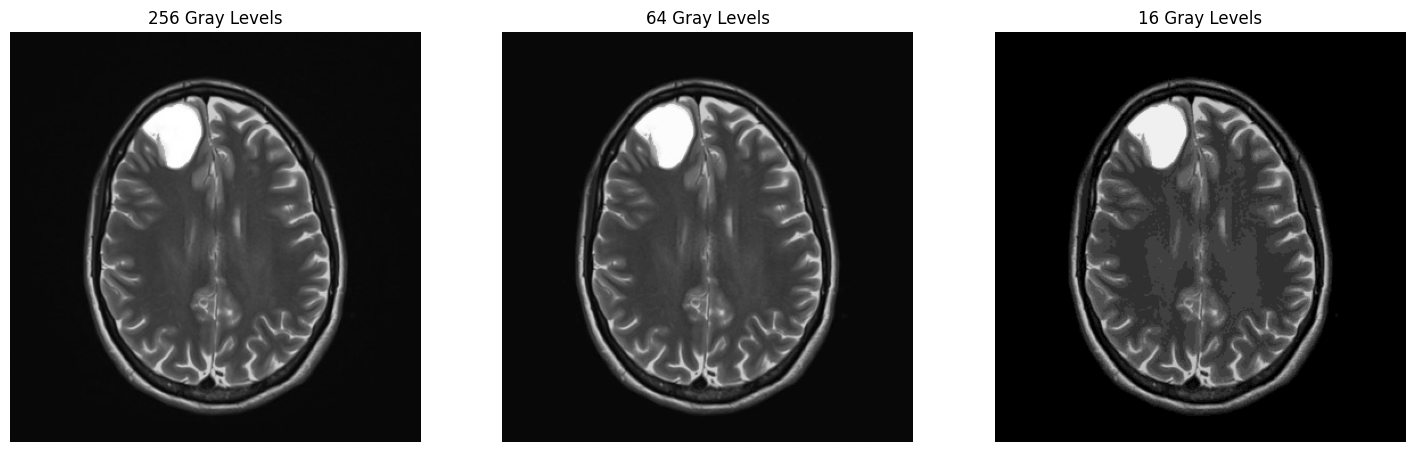

In [29]:
# 2. 定义灰度量化函数
def reduce_gray_levels(img, n):
    """
    将灰度图像量化为 2^n 个灰度级
    img: 输入图像 (np.ndarray)
    n: 灰度级参数，灰度级数为 2^n
    返回量化后的图像
    """
    levels = 2 ** n
    step = 256 // levels  # 每个灰度级的步长
    img_out = (img // step) * step
    return img_out.astype(np.uint8)

# 3. 生成不同灰度级的图像
img_256 = reduce_gray_levels(image, 8)   # 256级灰度
img_64  = reduce_gray_levels(image, 6)   # 64级灰度
img_16  = reduce_gray_levels(image, 4)   # 16级灰度

# 4. 显示图像
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_256, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('256 Gray Levels')
axes[0].axis('off')

axes[1].imshow(img_64, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('64 Gray Levels')
axes[1].axis('off')

axes[2].imshow(img_16, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('16 Gray Levels')
axes[2].axis('off')

plt.show()